## question 1

In [36]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import MinMaxScaler

In [37]:
data_set = pd.read_csv("/content/heart_disease_uci.csv")
display(data_set.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Identifying missing values

In [38]:
missing_values = data_set.isnull().sum()
print("Missing values before dropping rows:\n", missing_values[missing_values > 0])

Missing values before dropping rows:
 trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


### Dropping rows with missing values

In [39]:
print(f"Shape of data_set before dropping rows: {data_set.shape}")
data_set.dropna(inplace=True)
print(f"Shape of data_set after dropping rows: {data_set.shape}")

# Verify that there are no more missing values
missing_values_after_drop = data_set.isnull().sum()
print("\nMissing values after dropping rows:\n", missing_values_after_drop[missing_values_after_drop > 0])

Shape of data_set before dropping rows: (920, 16)
Shape of data_set after dropping rows: (299, 16)

Missing values after dropping rows:
 Series([], dtype: int64)


Remove any duplicate rows in the dataset (if applicable).

In [6]:
duplicate_rows = data_set[data_set.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [id, age, sex, dataset, cp, trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, ca, thal, num]
Index: []


# For columns with missing values, replace the missing values in the age&3 column with the mean and in the cholesterol column with the median.

In [11]:
miss_age=data_set["age"].isnull().sum()
mean_age=data_set["age"].mean()
data_set["age"].fillna(mean_age,inplace=True)
miss_chol=data_set["chol"].isnull().sum()
median_chol=data_set["chol"].median()
data_set["chol"].fillna(median_chol,inplace=True)

/tmp/ipykernel_1318/4072007447.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_set["age"].fillna(mean_age,inplace=True)
/tmp/ipykernel_1318/4072007447.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [13]:
print(data_set["chol"].isnull().sum())

0


5. Use the IQR method to detect potential outliers in the &#39;cholesterol&#39; column. List all outliers

In [15]:
q1=data_set["chol"].quantile(0.25)
q3=data_set["chol"].quantile(0.75)
IQR = q3-q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers = data_set[(data_set["chol"] < lower_bound) | (data_set["chol"] > upper_bound)]
print(outliers)

      id  age     sex        dataset            cp  trestbps   chol    fbs  \
48    49   65  Female      Cleveland   non-anginal     140.0  417.0   True   
121  122   63  Female      Cleveland  asymptomatic     150.0  407.0  False   
152  153   67  Female      Cleveland   non-anginal     115.0  564.0  False   
173  174   62  Female      Cleveland  asymptomatic     140.0  394.0  False   
181  182   56  Female      Cleveland  asymptomatic     134.0  409.0  False   
748  749   56    Male  VA Long Beach  asymptomatic     120.0  100.0  False   

            restecg  thalch  exang  oldpeak      slope   ca  \
48   lv hypertrophy   157.0  False      0.8  upsloping  1.0   
121  lv hypertrophy   154.0  False      4.0       flat  3.0   
152  lv hypertrophy   160.0  False      1.6       flat  0.0   
173  lv hypertrophy   157.0  False      1.2       flat  0.0   
181  lv hypertrophy   150.0   True      1.9       flat  2.0   
748          normal   120.0   True      1.5       flat  0.0   

           

Use the KNN Imputer to replace missing values in the dataset. Compare the results of the KNN
Imputer to mean and median imputation.

In [22]:
knn_data=pd.read_csv("/content/heart_disease_uci.csv")
knn_imputer = KNNImputer(n_neighbors=5)
feature_cols = [c for c in knn_data.select_dtypes(include=[np.number]).columns if c != 'id']
X = knn_data[feature_cols].copy()
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)
X_knn_scaled = knn_imputer.fit_transform(X_scaled)


In [23]:
mean_imputer = SimpleImputer(strategy='mean')
df_mean = pd.DataFrame(mean_imputer.fit_transform(X), columns=feature_cols, index=X.index)

# Median Imputation
median_imputer = SimpleImputer(strategy='median')
df_median = pd.DataFrame(median_imputer.fit_transform(X), columns=feature_cols, index=X.index)

In [28]:
target_col = 'ca' if 'ca' in X.columns else feature_cols[0]
missing_indices = X[X[target_col].isnull()].index

comparison_df = pd.DataFrame({
    'Original (Missing)': X.loc[missing_indices, target_col],
    'Mean Imputed': df_mean.loc[missing_indices, target_col],
    'Median Imputed': df_median.loc[missing_indices, target_col],
    'KNN Imputed': knn_data.loc[missing_indices, target_col].round(2)
})

print(comparison_df.head(10))


     Original (Missing)  Mean Imputed  Median Imputed  KNN Imputed
166                 NaN      0.676375             0.0          NaN
192                 NaN      0.676375             0.0          NaN
287                 NaN      0.676375             0.0          NaN
302                 NaN      0.676375             0.0          NaN
303                 NaN      0.676375             0.0          NaN
304                 NaN      0.676375             0.0          NaN
305                 NaN      0.676375             0.0          NaN
306                 NaN      0.676375             0.0          NaN
307                 NaN      0.676375             0.0          NaN
308                 NaN      0.676375             0.0          NaN


In [29]:
stats = pd.DataFrame({
    'Original (dropna)': [X[target_col].mean(), X[target_col].std()],
    'Mean Imputed': [df_mean[target_col].mean(), df_mean[target_col].std()],
    'Median Imputed': [df_median[target_col].mean(), df_median[target_col].std()],
    'KNN Imputed': [knn_data[target_col].mean(), knn_data[target_col].std()]
}, index=['Mean', 'Std Dev'])

print(stats)

         Original (dropna)  Mean Imputed  Median Imputed  KNN Imputed
Mean              0.676375      0.676375        0.227174     0.676375
Std Dev           0.935653      0.541667        0.628936     0.935653


7. Standardize the text values in a categorical column (e.g., converting text to lowercase, ensuring
consistent labels). Check for and remove any duplicates in the &#39;patient ID&#39; column (if applicable).

### Standardizing text values in categorical columns

In [41]:
# Identify categorical columns with object dtype
categorical_cols = data_set.select_dtypes(include=['object']).columns

# Standardize text values (lowercase and strip whitespace)
for col in categorical_cols:
    if col != 'id': # 'id' is typically numeric or unique identifier, not for text standardization
        data_set[col] = data_set[col].astype(str).str.lower().str.strip()

print("Standardized categorical columns:")
for col in categorical_cols:
    if col != 'id':
        print(f"Column '{col}' unique values: {data_set[col].unique()}")

Standardized categorical columns:
Column 'sex' unique values: ['male' 'female']
Column 'dataset' unique values: ['cleveland' 'hungary' 'va long beach']
Column 'cp' unique values: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
Column 'fbs' unique values: ['true' 'false']
Column 'restecg' unique values: ['lv hypertrophy' 'normal' 'st-t abnormality']
Column 'exang' unique values: ['false' 'true']
Column 'slope' unique values: ['downsloping' 'flat' 'upsloping']
Column 'thal' unique values: ['fixed defect' 'normal' 'reversable defect']


### Checking and removing duplicate 'patient ID' (id) rows

In [42]:
print(f"Shape of data_set before removing ID duplicates: {data_set.shape}")
duplicate_ids = data_set[data_set.duplicated(subset=['id'], keep=False)]

if not duplicate_ids.empty:
    print(f"\nDuplicate 'id' rows found:\n{duplicate_ids}")
    data_set.drop_duplicates(subset=['id'], inplace=True)
    print(f"Shape of data_set after removing ID duplicates: {data_set.shape}")
else:
    print("\nNo duplicate 'id' rows found.")

Shape of data_set before removing ID duplicates: (299, 16)

No duplicate 'id' rows found.


# **Question 2**

In [46]:
employe=pd.read_csv("/content/question2.csv")
employe.head(10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [47]:
print(f"Shape of employe DataFrame before dropping rows: {employe.shape}")
employe.columns.tolist()


Shape of employe DataFrame before dropping rows: (1470, 35)


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [48]:
import numpy as np

columns_to_introduce_missing = ['MonthlyIncome', 'JobSatisfaction']

for col in columns_to_introduce_missing:
    if col in employe.columns:
        # Calculate 30% of the non-missing values
        num_missing_to_introduce = int(len(employe[col].dropna()) * 0.30)

        # Get non-missing indices
        non_missing_indices = employe[employe[col].notna()].index

        # Randomly select indices to set to NaN
        indices_to_set_nan = np.random.choice(non_missing_indices, num_missing_to_introduce, replace=False)

        # Introduce NaN values
        employe.loc[indices_to_set_nan, col] = np.nan
        print(f"Introduced {num_missing_to_introduce} missing values in '{col}'.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Cannot introduce missing values.")

print("\nMissing values after introducing 30% for specified columns:")
print(employe[columns_to_introduce_missing].isnull().sum())

Introduced 441 missing values in 'MonthlyIncome'.
Introduced 441 missing values in 'JobSatisfaction'.

Missing values after introducing 30% for specified columns:
MonthlyIncome      441
JobSatisfaction    441
dtype: int64


Drop rows that contain missing values in the &#39;Job Satisfaction&#39; and &#39;Monthly Income&#39; columns.

In [49]:
print(f"Shape of employe DataFrame before dropping rows: {employe.shape}")

employe.dropna(subset=['JobSatisfaction', 'MonthlyIncome'], inplace=True)

print(f"Shape of employe DataFrame after dropping rows: {employe.shape}")
print("\nMissing values in 'JobSatisfaction' and 'MonthlyIncome' after dropping rows:")
print(employe[['JobSatisfaction', 'MonthlyIncome']].isnull().sum())

Shape of employe DataFrame before dropping rows: (1470, 35)
Shape of employe DataFrame after dropping rows: (734, 35)

Missing values in 'JobSatisfaction' and 'MonthlyIncome' after dropping rows:
JobSatisfaction    0
MonthlyIncome      0
dtype: int64


For the columns with missing values, apply mean imputation for the &#39;Monthly Income&#39; column
and mode imputation for the &#39;Job Satisfaction&#39; column.

### Applying Mean and Mode Imputation

In [50]:
# Apply mean imputation for 'MonthlyIncome'
mean_income_imputer = SimpleImputer(strategy='mean')
employe['MonthlyIncome'] = mean_income_imputer.fit_transform(employe[['MonthlyIncome']])

# Apply mode imputation for 'JobSatisfaction'
mode_satisfaction_imputer = SimpleImputer(strategy='most_frequent')
employe['JobSatisfaction'] = mode_satisfaction_imputer.fit_transform(employe[['JobSatisfaction']])

print("Missing values after imputation:")
print(employe[['MonthlyIncome', 'JobSatisfaction']].isnull().sum())

print("\nFirst 5 rows of 'MonthlyIncome' after mean imputation:")
print(employe['MonthlyIncome'].head())

print("\nFirst 5 rows of 'JobSatisfaction' after mode imputation:")
print(employe['JobSatisfaction'].head())

Missing values after imputation:
MonthlyIncome      0
JobSatisfaction    0
dtype: int64

First 5 rows of 'MonthlyIncome' after mean imputation:
0     5993.0
2     2090.0
5     3068.0
8     9526.0
12    2911.0
Name: MonthlyIncome, dtype: float64

First 5 rows of 'JobSatisfaction' after mode imputation:
0     4.0
2     3.0
5     4.0
8     3.0
12    3.0
Name: JobSatisfaction, dtype: float64


### Detecting Outliers in 'Monthly Income' using Z-score

In [51]:
# Calculate mean and standard deviation for 'MonthlyIncome'
mean_monthly_income = employe['MonthlyIncome'].mean()
std_monthly_income = employe['MonthlyIncome'].std()

# Calculate Z-scores for 'MonthlyIncome'
employe['MonthlyIncome_Zscore'] = (employe['MonthlyIncome'] - mean_monthly_income) / std_monthly_income

# Identify outliers based on a Z-score threshold of ±3
outliers_zscore = employe[(employe['MonthlyIncome_Zscore'] > 3) | (employe['MonthlyIncome_Zscore'] < -3)]

print("Outliers in 'Monthly Income' based on Z-score threshold of ±3:")
display(outliers_zscore[['MonthlyIncome', 'MonthlyIncome_Zscore']])

Outliers in 'Monthly Income' based on Z-score threshold of ±3:


,MonthlyIncome,MonthlyIncome_Zscore


### Identifying Noisy Data in 'Age' and 'Total Working Years'

In [52]:
# Check for implausible ages (e.g., age < 18 or age > 100)
noisy_age_low = employe[employe['Age'] < 18]
noisy_age_high = employe[employe['Age'] > 100]

print("Rows with implausibly low 'Age' (below 18):")
display(noisy_age_low[['Age', 'TotalWorkingYears']])

print("\nRows with implausibly high 'Age' (above 100):")
display(noisy_age_high[['Age', 'TotalWorkingYears']])

# Check for implausible 'TotalWorkingYears' (e.g., negative or greater than age)
noisy_total_working_years_negative = employe[employe['TotalWorkingYears'] < 0]
noisy_total_working_years_too_high = employe[employe['TotalWorkingYears'] > employe['Age'] - 15] # Assuming typical working age starts around 15

print("\nRows with negative 'TotalWorkingYears':")
display(noisy_total_working_years_negative[['Age', 'TotalWorkingYears']])

print("\nRows where 'TotalWorkingYears' is implausibly high relative to 'Age' (Age - 15):")
display(noisy_total_working_years_too_high[['Age', 'TotalWorkingYears']])

Rows with implausibly low 'Age' (below 18):


,Age,TotalWorkingYears



Rows with implausibly high 'Age' (above 100):


,Age,TotalWorkingYears



Rows with negative 'TotalWorkingYears':


,Age,TotalWorkingYears



Rows where 'TotalWorkingYears' is implausibly high relative to 'Age' (Age - 15):


,Age,TotalWorkingYears


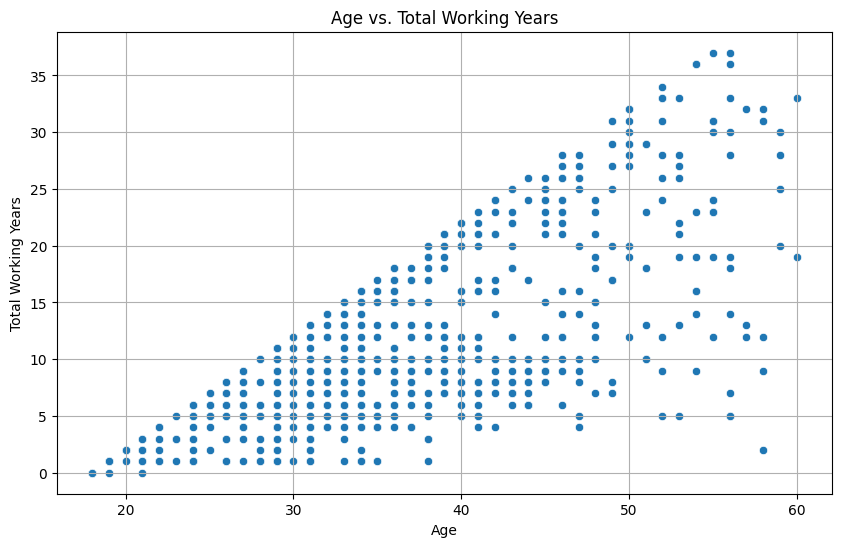

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship between Age and TotalWorkingYears to identify outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='TotalWorkingYears', data=employe)
plt.title('Age vs. Total Working Years')
plt.xlabel('Age')
plt.ylabel('Total Working Years')
plt.grid(True)
plt.show()

### Handling Missing Values in 'YearsAtCompany' using Interpolation, Mean, and Mode Imputation

In [ ]:
# Introduce 10% missing values into 'YearsAtCompany' for demonstration
np.random.seed(42) # for reproducibility
missing_percent = 0.10
num_missing_years = int(len(employe) * missing_percent)

# Get non-missing indices for 'YearsAtCompany'
non_missing_indices_years = employe[employe['YearsAtCompany'].notna()].index

# Randomly select indices to set to NaN
indices_to_set_nan_years = np.random.choice(non_missing_indices_years, num_missing_years, replace=False)

employe_missing = employe.copy() # Create a copy to introduce missing values
employe_missing.loc[indices_to_set_nan_years, 'YearsAtCompany'] = np.nan

print(f"Introduced {num_missing_years} missing values in 'YearsAtCompany'.")
print("Missing values in 'YearsAtCompany' after introduction:", employe_missing['YearsAtCompany'].isnull().sum())

# Store original (with introduced NaNs) for comparison
original_years_at_company = employe_missing['YearsAtCompany'].copy()


In [ ]:
from sklearn.impute import SimpleImputer

# 1. Interpolation Imputation
employe_interpolated = employe_missing.copy()
employe_interpolated['YearsAtCompany'] = employe_interpolated['YearsAtCompany'].interpolate(method='linear')

# 2. Mean Imputation
mean_imputer_years = SimpleImputer(strategy='mean')
employe_mean_imputed = employe_missing.copy()
employe_mean_imputed['YearsAtCompany'] = mean_imputer_years.fit_transform(employe_mean_imputed[['YearsAtCompany']])

# 3. Mode Imputation
mode_imputer_years = SimpleImputer(strategy='most_frequent')
employe_mode_imputed = employe_missing.copy()
employe_mode_imputed['YearsAtCompany'] = mode_imputer_years.fit_transform(employe_mode_imputed[['YearsAtCompany']])

print("Comparison of 'YearsAtCompany' statistics after different imputations:")
comparison_stats = pd.DataFrame({
    'Original (with NaNs)': original_years_at_company.describe(),
    'Interpolated': employe_interpolated['YearsAtCompany'].describe(),
    'Mean Imputed': employe_mean_imputed['YearsAtCompany'].describe(),
    'Mode Imputed': employe_mode_imputed['YearsAtCompany'].describe()
})
display(comparison_stats)

# Display a sample of imputed values where NaNs were introduced
sample_missing_indices = original_years_at_company[original_years_at_company.isnull()].index[:10]

comparison_values = pd.DataFrame({
    'Original (with NaNs)': original_years_at_company.loc[sample_missing_indices],
    'Interpolated': employe_interpolated['YearsAtCompany'].loc[sample_missing_indices],
    'Mean Imputed': employe_mean_imputed['YearsAtCompany'].loc[sample_missing_indices],
    'Mode Imputed': employe_mode_imputed['YearsAtCompany'].loc[sample_missing_indices]
})
print("\nSample of imputed values for 'YearsAtCompany':")
display(comparison_values)

Use the Z-score method to detect potential outliers in the &#39;Monthly Income&#39; column. List any
values that fall outside a Z-score threshold of ±3.